In [25]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_validation import validate_data

In [26]:
data_path = project_root/"data"/"interim"/"all_counties_processed_no_fire_2006_2024.csv"
output_dir = project_root/"results"/"ar"

data = pd.read_csv(data_path, parse_dates=["Year-Month"])

validate_data(data=data,
              required_columns=[
                  "County",
                  "Year-Month",
                  "rate_per_100k",
              ],
              county_col = "County",
              date_col = "Year-Month",
              )

print(f"Loaded {len(data)} rows of data from {data_path}")

Required-column check passed.
Duplicate-row check passed.
Monthly-continuity check passed.
Loaded 1768 rows of data from c:\Users\austi\Documents\VS Code Projects\ValleyFever-MediaSignals\data\interim\all_counties_processed_no_fire_2006_2024.csv


In [29]:
def ar_model(
    county,
    evaluation_date,
    data=data,
    horizons=(1, 3, 6),
    n_lags=12,
    output_dir=output_dir,
):
    """
    Train separate multi-output AR models for 1-, 3-, and
    6-month horizons from one fixed historical date.
    """

    county_data = (
        data[data["County"] == county]
        .sort_values("Year-Month")
    )

    rate = county_data.set_index("Year-Month")["rate_per_100k"]

    evaluation_date = pd.Timestamp(evaluation_date)
    training_rate = rate.loc[:evaluation_date]
    forecast_origin = training_rate.index[-1]

    feature_columns = [
        f"rate_lag_{lag}"
        for lag in range(n_lags)
    ]

    latest_features = pd.DataFrame(
        [training_rate.iloc[-n_lags:].to_numpy()[::-1]],
        columns=feature_columns,
    )

    forecast_rows = []

    for horizon in horizons:
        model_data = pd.DataFrame(index=training_rate.index)

        # Create autoregressive inputs.
        for lag in range(n_lags):
            model_data[f"rate_lag_{lag}"] = training_rate.shift(lag)

        # Create one target for each month in the horizon.
        target_columns = []

        for lead_month in range(1, horizon + 1):
            target_column = f"target_{lead_month}"

            model_data[target_column] = training_rate.shift(
                -lead_month
            )

            target_columns.append(target_column)

        model_data = model_data.dropna()

        X = model_data[feature_columns]
        y = model_data[target_columns]

        model = LinearRegression()
        model.fit(X, y)

        predictions = model.predict(latest_features)[0]

        target_dates = [
            forecast_origin + pd.DateOffset(months=lead_month)
            for lead_month in range(1, horizon + 1)
        ]

        actual_values = rate.loc[target_dates].to_numpy()

        rmse = np.sqrt(
            mean_squared_error(actual_values, predictions)
        )

        mae = mean_absolute_error(
            actual_values,
            predictions,
        )

        for lead_month, target_date, prediction, actual in zip(
            range(1, horizon + 1),
            target_dates,
            predictions,
            actual_values,
        ):
            forecast_rows.append(
                {
                    "County": county,
                    "Model": f"AR({n_lags})",
                    "Forecast_Horizon": horizon,
                    "Lead_Month": lead_month,
                    "Forecast_Origin": forecast_origin,
                    "Target_Date": target_date,
                    "Prediction": prediction,
                    "Actual": actual,
                    "Error": prediction - actual,
                    "RMSE": rmse,
                    "MAE": mae,
                }
            )

    forecast_df = pd.DataFrame(forecast_rows)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    county_slug = county.lower().replace(" ", "_")
    date_slug = forecast_origin.strftime("%Y-%m")

    csv_path = (
        output_dir
        / f"{county_slug}_ar_evaluation_{date_slug}.csv"
    )

    graph_path = (
        output_dir
        / f"{county_slug}_ar_evaluation_{date_slug}.png"
    )

    forecast_df.to_csv(
        csv_path,
        index=False,
        date_format="%Y-%m-%d",
    )

    # Create one subplot for each forecast horizon.
    fig, axes = plt.subplots(
        len(horizons),
        1,
        figsize=(12, 5 * len(horizons)),
    )

    for ax, horizon in zip(axes, horizons):
        horizon_forecast = (
            forecast_df[
                forecast_df["Forecast_Horizon"] == horizon
            ]
            .sort_values("Lead_Month")
        )

        prediction_dates = [
            forecast_origin,
            *horizon_forecast["Target_Date"],
        ]

        prediction_values = [
            training_rate.iloc[-1],
            *horizon_forecast["Prediction"],
        ]

        actual_dates = [
            forecast_origin,
            *horizon_forecast["Target_Date"],
        ]

        actual_values = [
            training_rate.iloc[-1],
            *horizon_forecast["Actual"],
        ]

        # show the last three years of training data
        ax.plot(
            training_rate.tail(36).index,
            training_rate.tail(36),
            color="black",
            label="Observed training data",
        )

        ax.plot(
            actual_dates,
            actual_values,
            color="green",
            marker="o",
            label="True values",
        )

        ax.plot(
            prediction_dates,
            prediction_values,
            color="tab:blue",
            marker="o",
            linestyle="--",
            label="Predictions",
        )

        rmse = horizon_forecast["RMSE"].iloc[0]
        mae = horizon_forecast["MAE"].iloc[0]

        ax.axvline(
            forecast_origin,
            color="gray",
            linestyle=":",
            label="Forecast origin",
        )

        ax.set_title(
            f"{horizon}-Month Horizon | "
            f"RMSE: {rmse:.3f} | MAE: {mae:.3f}"
        )

        ax.set_xlabel("Month")
        ax.set_ylabel("Rate per 100,000")
        ax.grid(alpha=0.25)
        ax.legend()

    fig.suptitle(
        f"{county}: AR Forecast Evaluation",
        fontsize=15,
    )

    plt.tight_layout()

    plt.savefig(
        graph_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

    return forecast_df

In [32]:
counties = [
    "Fresno",
    "Kern",
    "Los Angeles",
    "Orange",
    "San Diego",
    "San Luis Obispo",
    "Tulare",
    "Ventura"
]

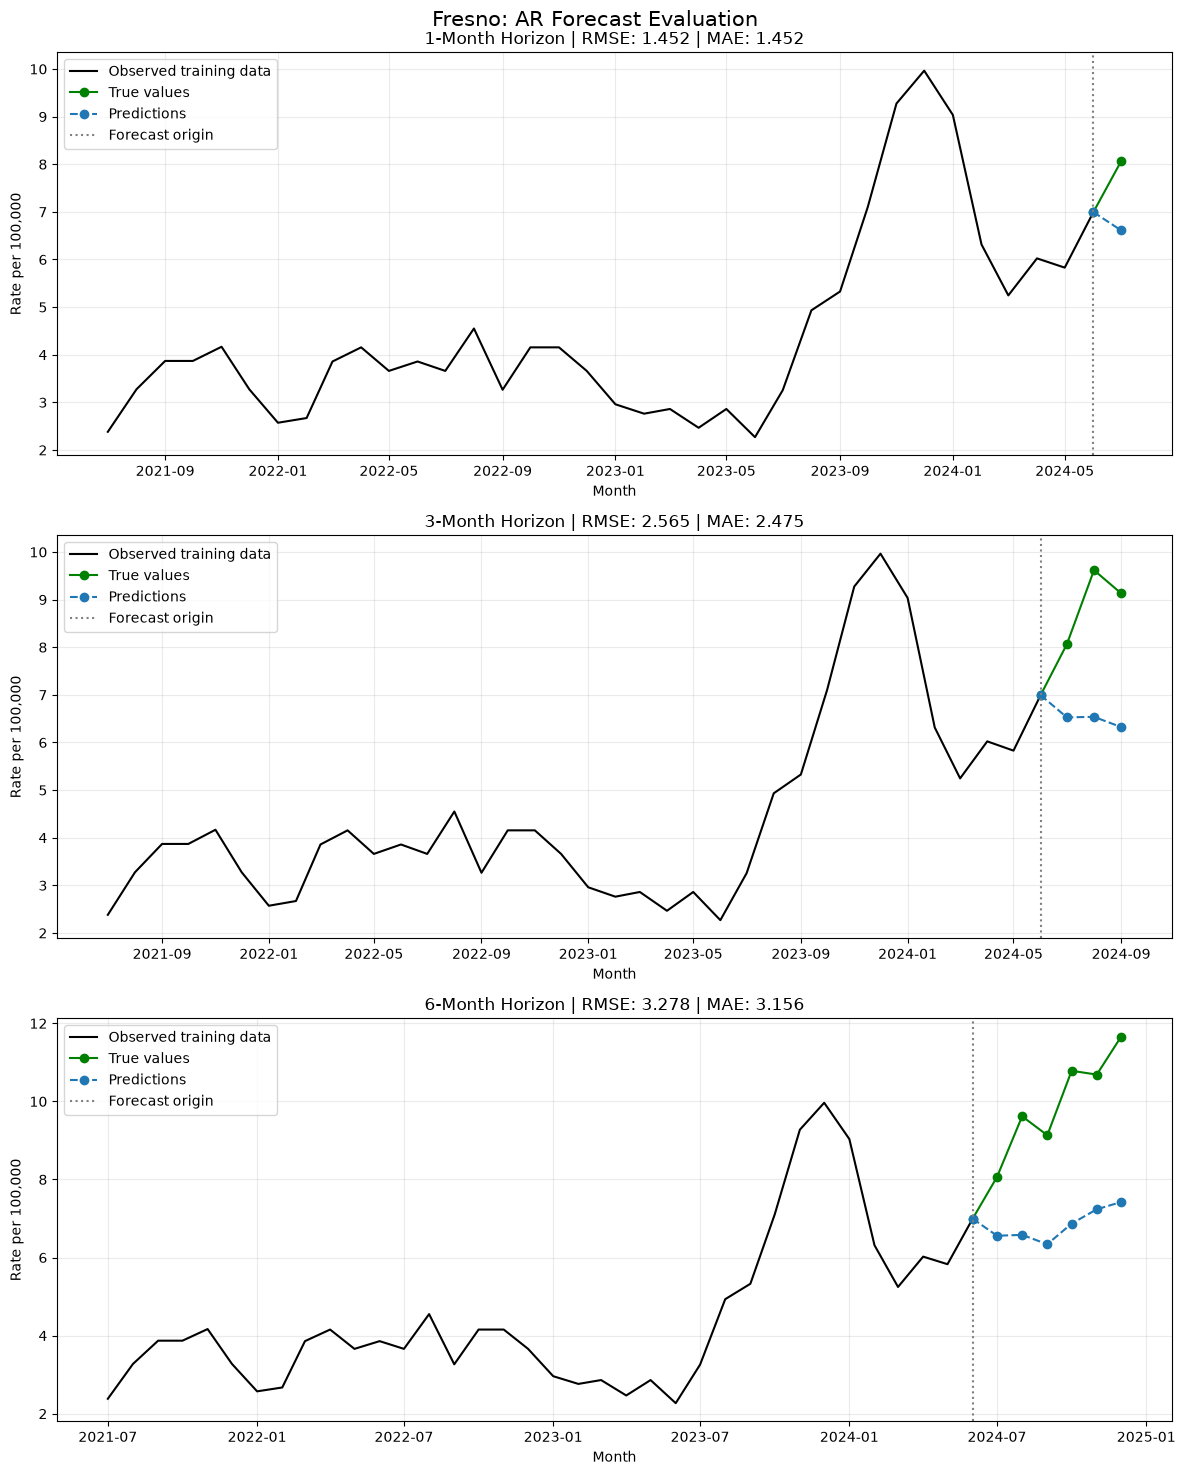

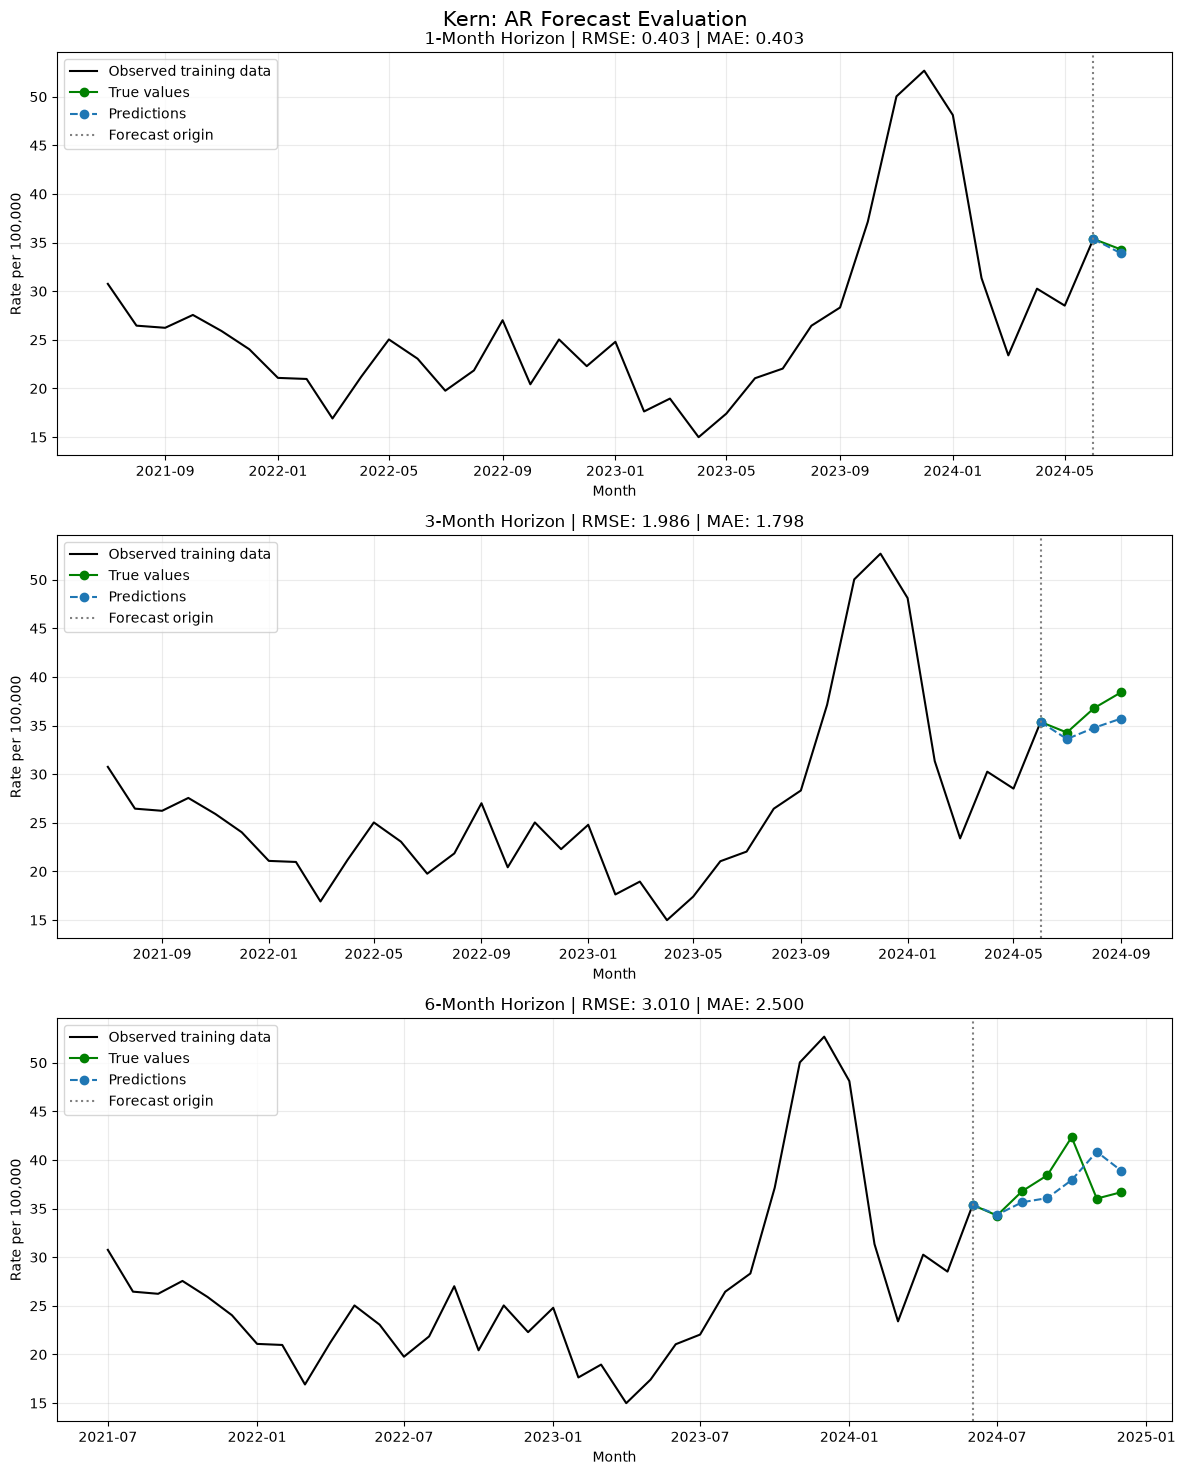

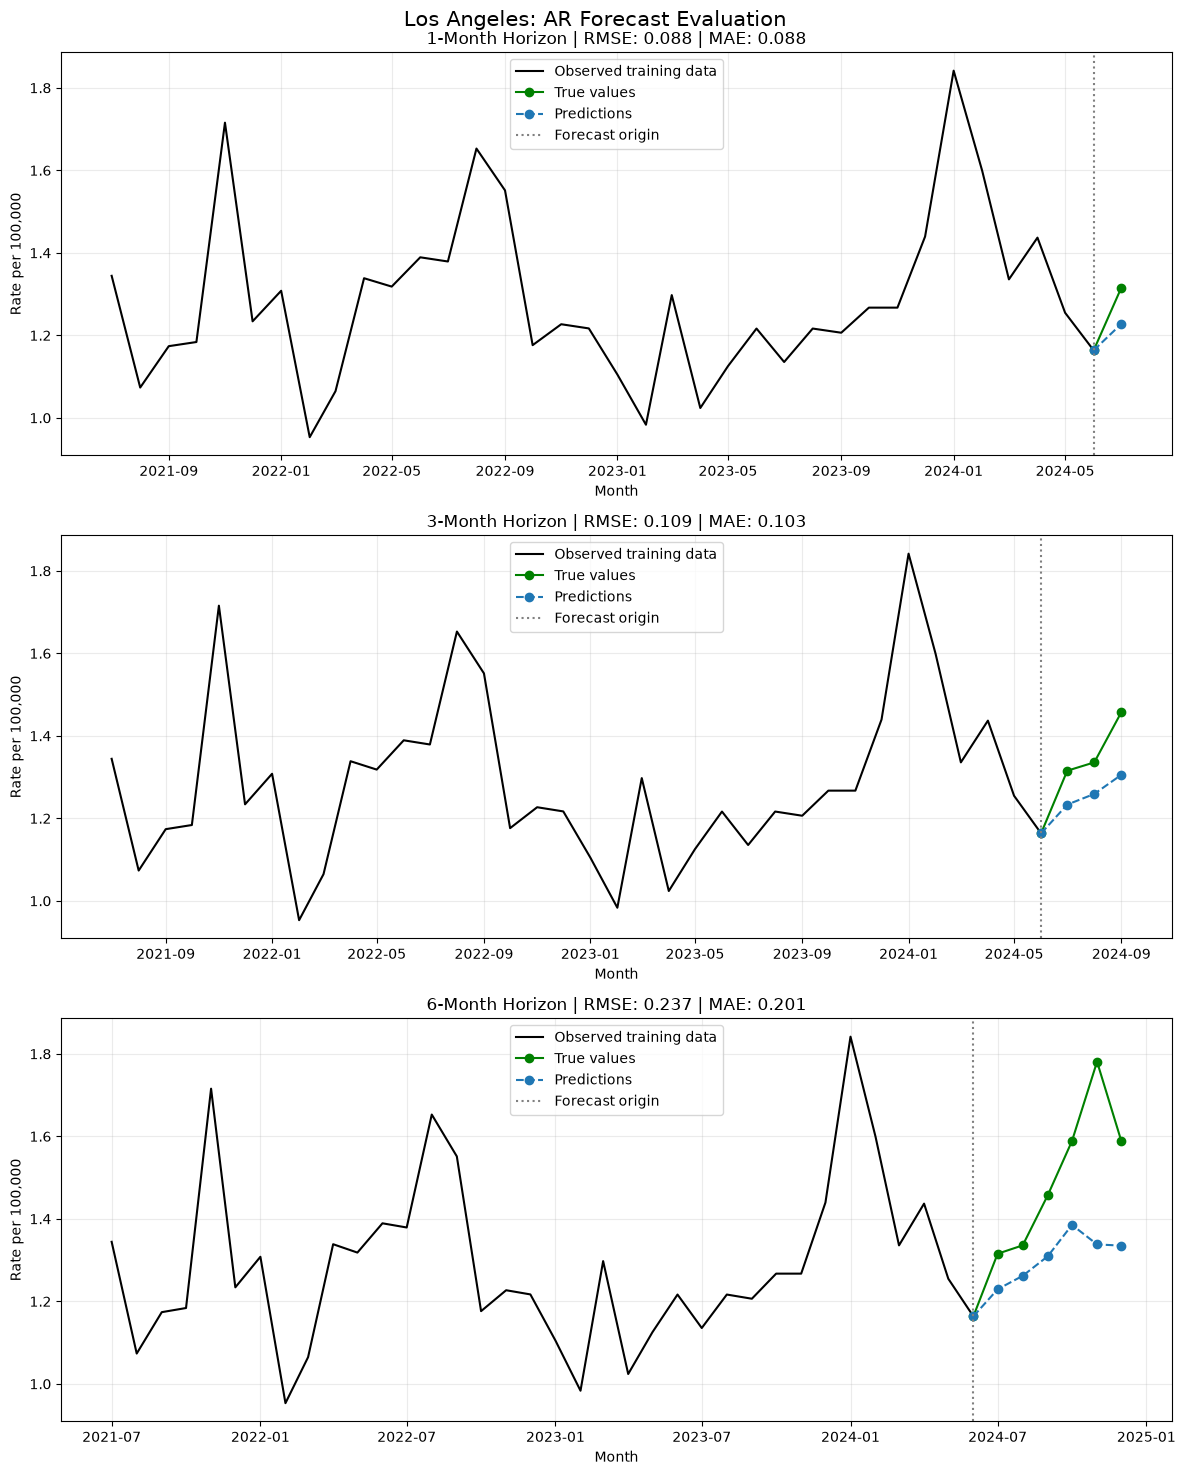

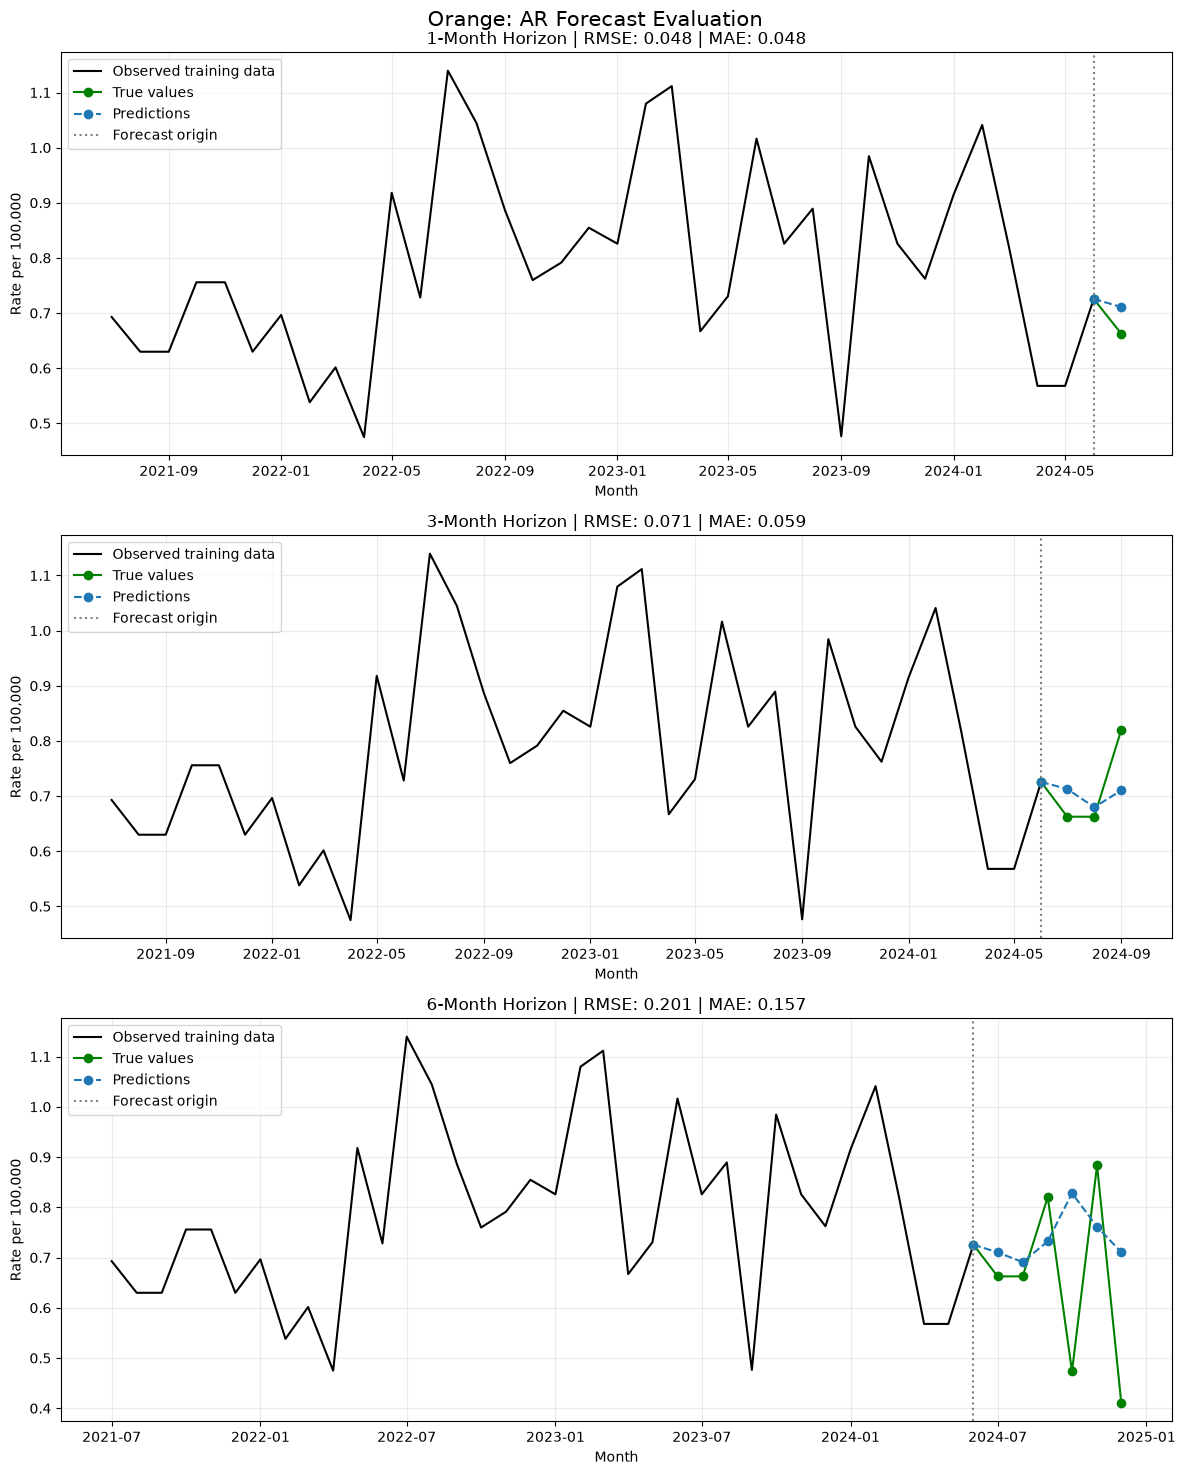

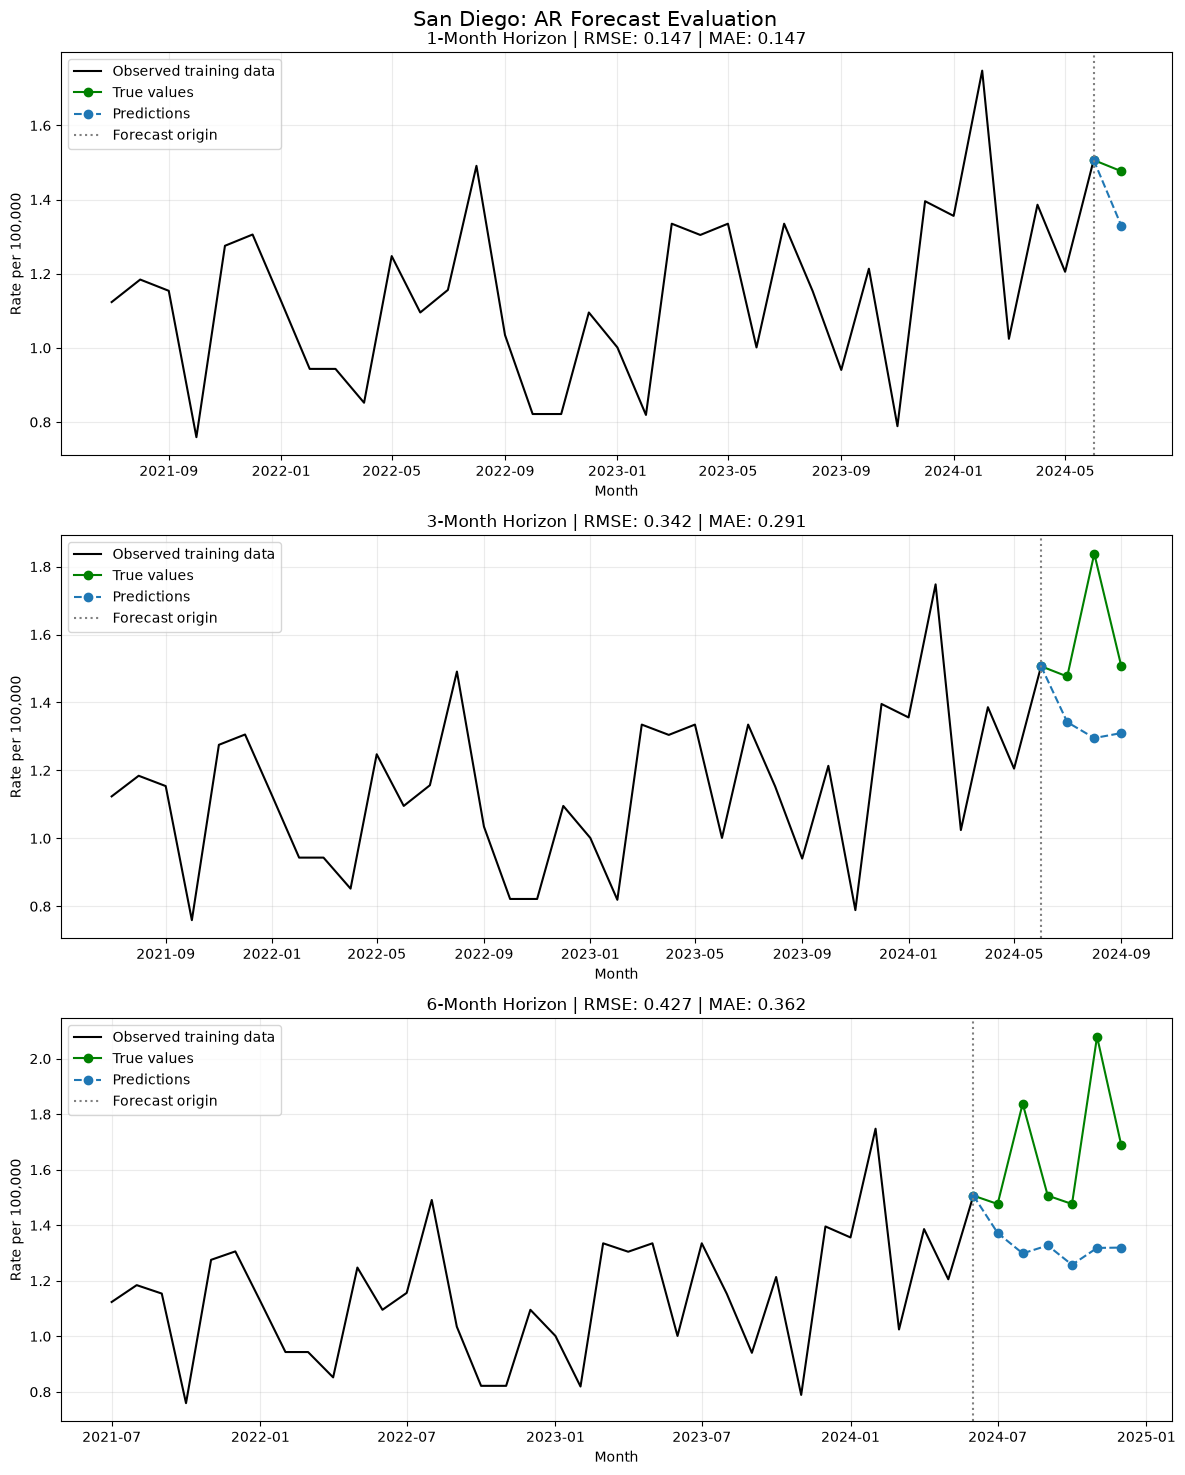

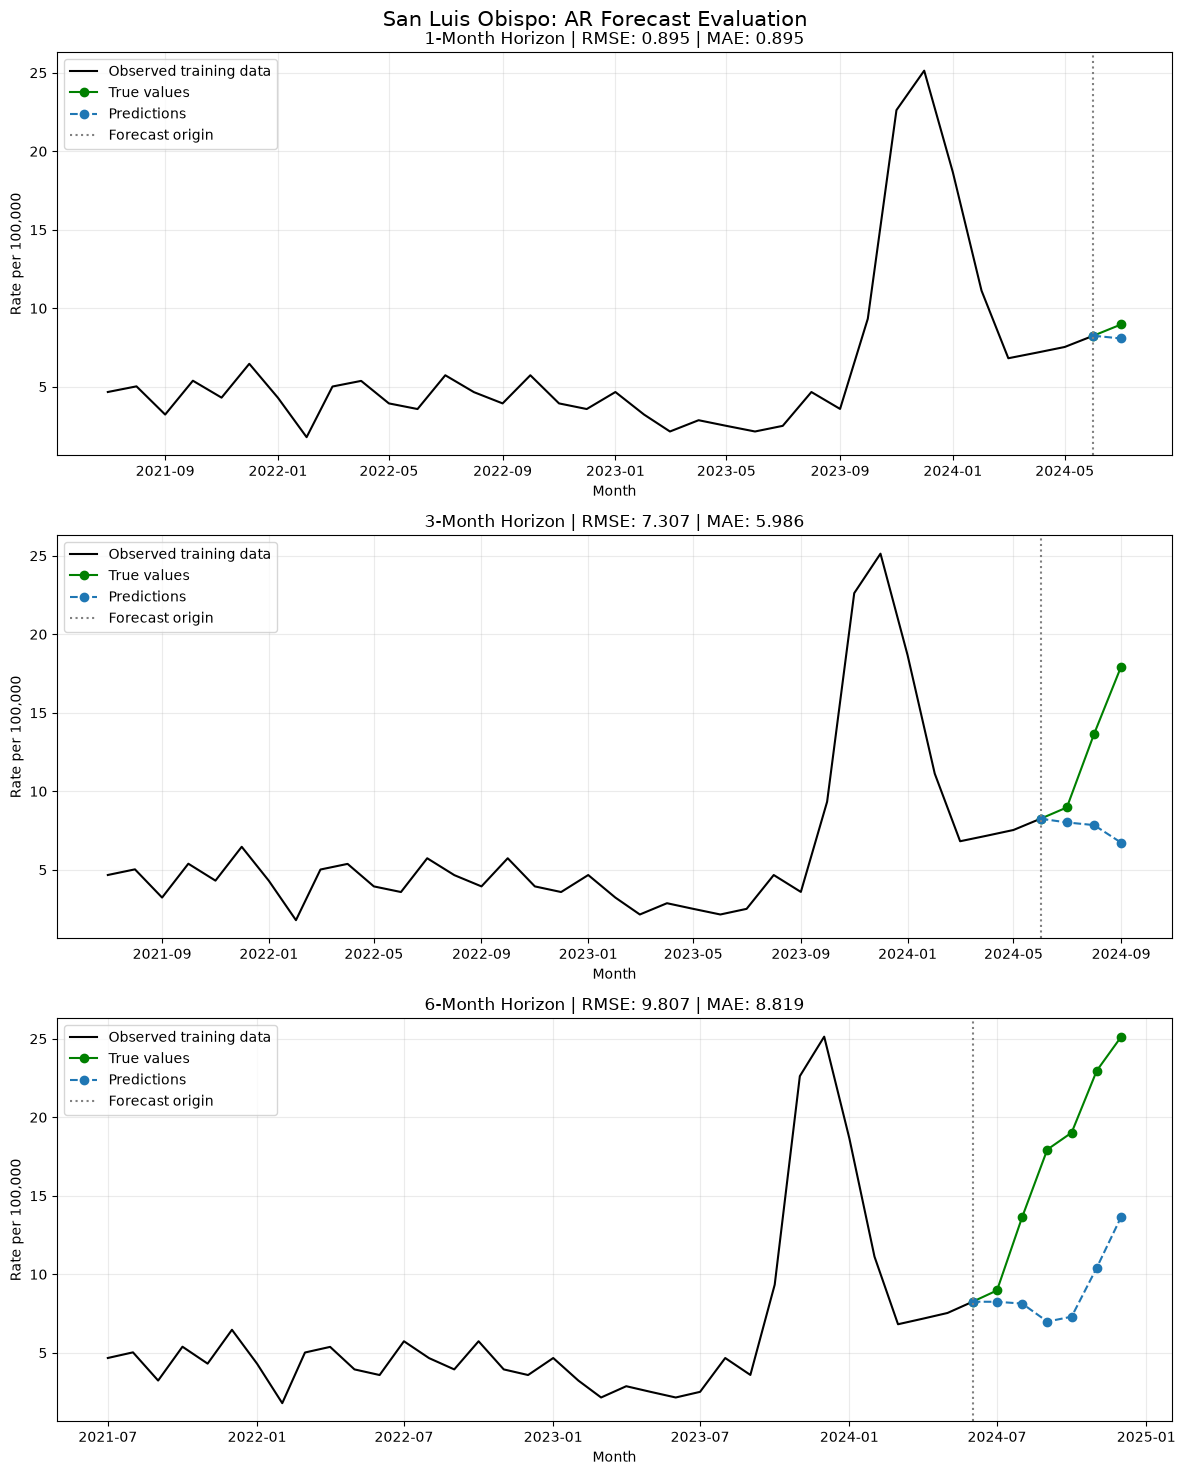

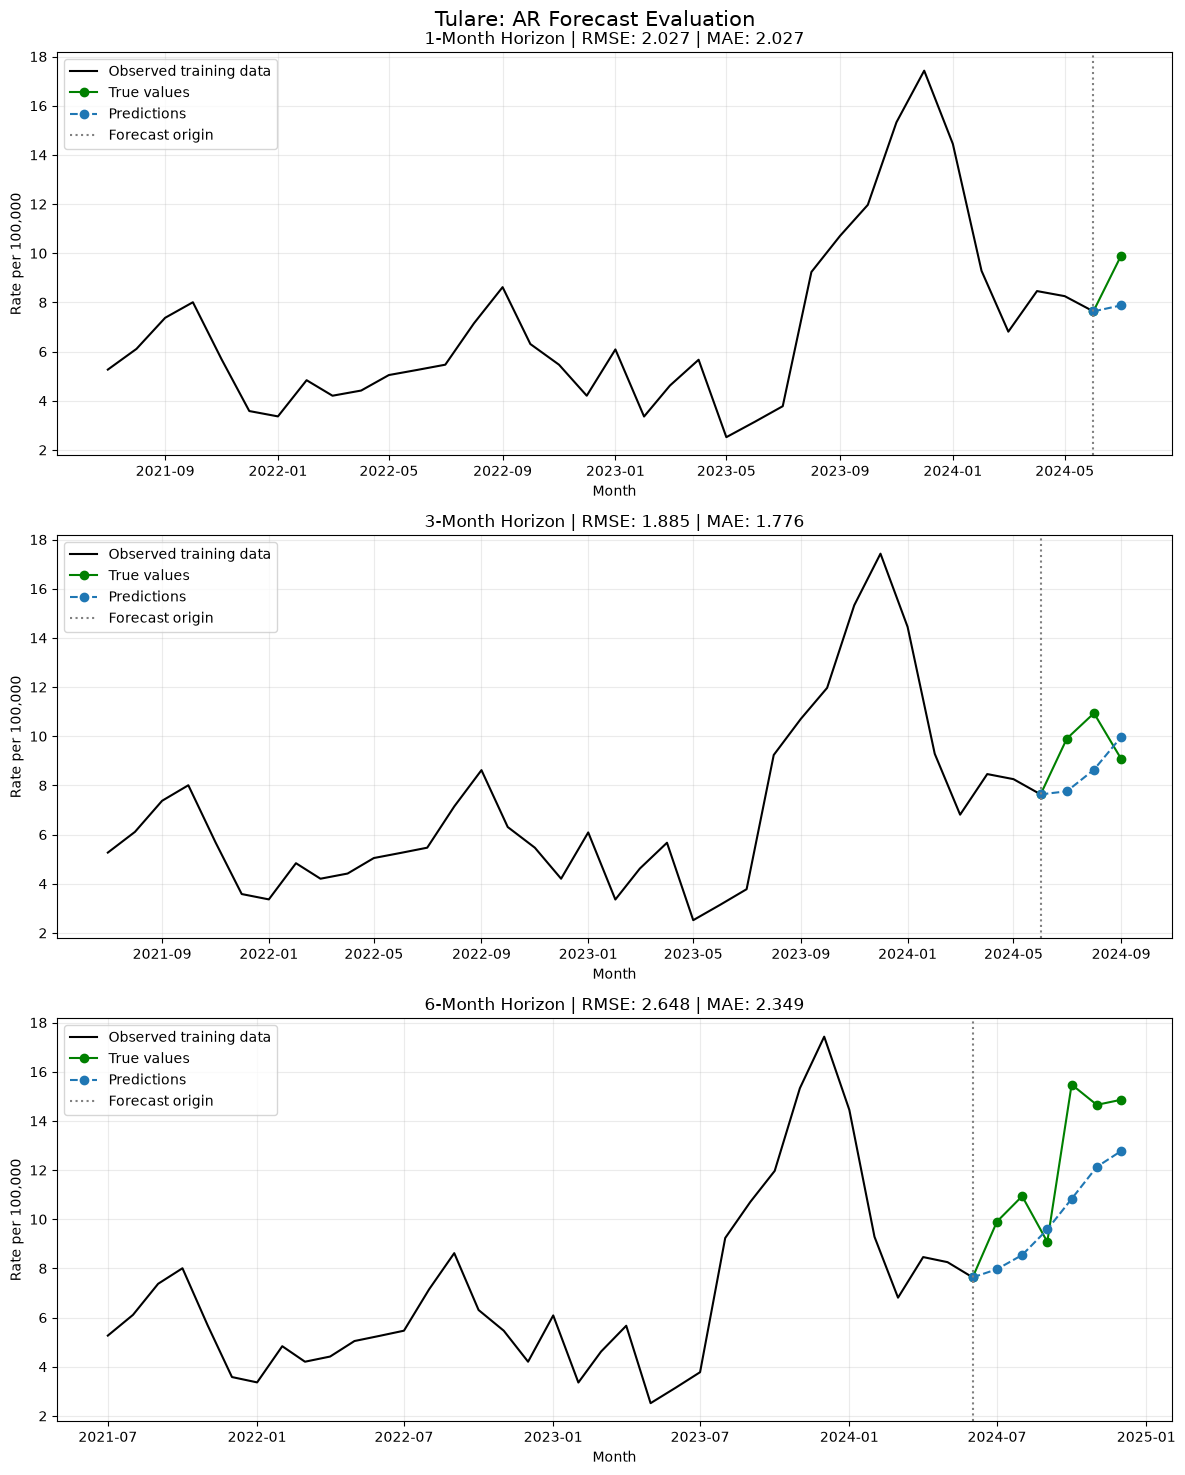

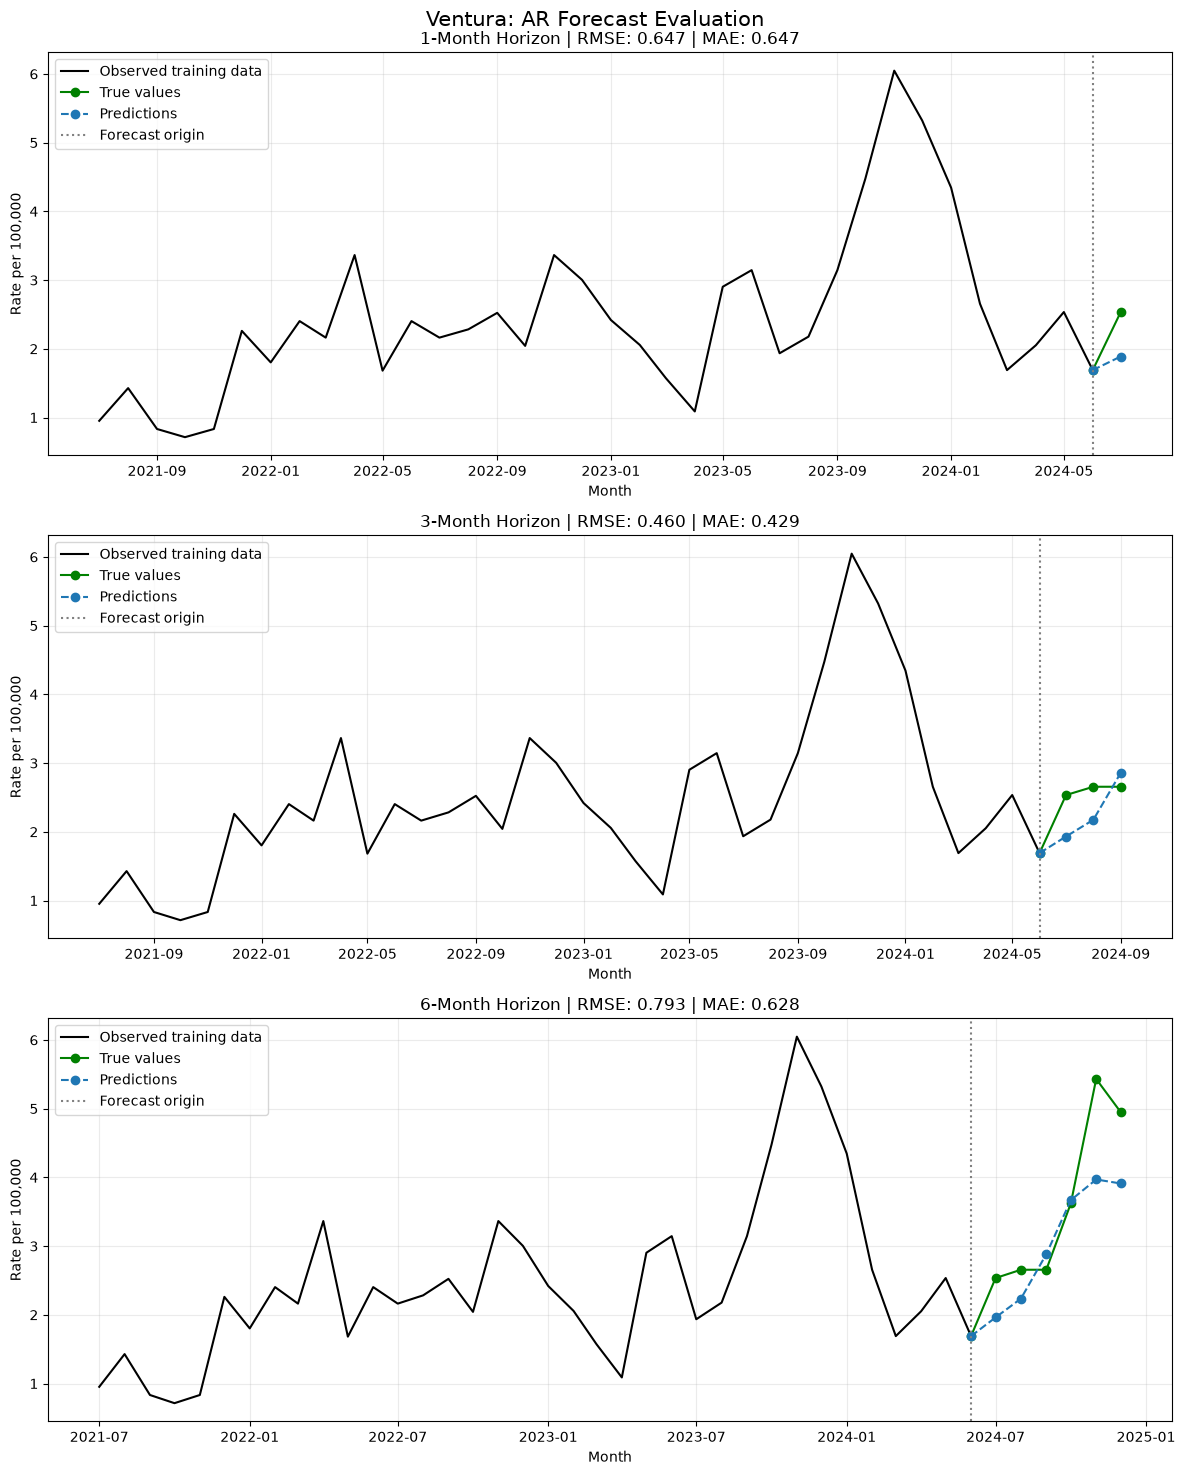

,County,Model,Forecast_Horizon,Lead_Month,Forecast_Origin,Target_Date,Prediction,Actual,Error,RMSE,MAE
0,Fresno,AR(12),1,1,2024-06-01,2024-07-01,6.611538,8.063874,-1.452336,1.452336,1.452336
1,Fresno,AR(12),3,1,2024-06-01,2024-07-01,6.527523,8.063874,-1.536351,2.564550,2.474747
2,Fresno,AR(12),3,2,2024-06-01,2024-08-01,6.538857,9.618355,-3.079498,2.564550,2.474747
3,Fresno,AR(12),3,3,2024-06-01,2024-09-01,6.324186,9.132580,-2.808393,2.564550,2.474747
4,Fresno,AR(12),6,1,2024-06-01,2024-07-01,6.558501,8.063874,-1.505372,3.277809,3.156041
...,...,...,...,...,...,...,...,...,...,...,...
75,Ventura,AR(12),6,2,2024-06-01,2024-08-01,2.235362,2.655587,-0.420225,0.793259,0.627897
76,Ventura,AR(12),6,3,2024-06-01,2024-09-01,2.881340,2.655587,0.225753,0.793259,0.627897
77,Ventura,AR(12),6,4,2024-06-01,2024-10-01,3.668609,3.621255,0.047353,0.793259,0.627897
78,Ventura,AR(12),6,5,2024-06-01,2024-11-01,3.969234,5.431883,-1.462649,0.793259,0.627897


In [34]:
all_results = []

for county in counties:
    results = ar_model(
        county=county,
        evaluation_date="2024-06-01",
        data=data,

        horizons=(1,3,6),
        n_lags=12,
        output_dir=output_dir
    )

    all_results.append(results)

all_forecasts = pd.concat(all_results, ignore_index=True)
display(all_forecasts)

all_forecasts.to_csv(
    output_dir/"all_counties_ar_evaluation_2024-06.csv",
    index=False,
    date_format="%Y-%m-%d",
)